In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(224, padding=4),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Downloading CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(
    root = './data', train = True,
    download = True, transform = train_transforms
)

print("Downloading CIFAR-10...")
testset = torchvision.datasets.CIFAR10(
    root = './data', train = False,
    download = True, transform = test_transforms
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size = 64,
    shuffle = True, num_workers = 2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size = 64,
    shuffle = False, num_workers = 2
)

classes = trainset.classes
print(f"Training images: {len(trainset)}")
print(f"Test images:     {len(testset)}")
print(f"Image size after resize: 224x224")

Training images: 50000
Test images:     10000
Image size after resize: 224x224


In [10]:
model_tl = models.resnet18(pretrained=True)
print("ResNet18 loaded with ImageNet weights")
print(f"Original final layer: {model_tl.fc}")
print(f"Original output: 1000 classes (ImageNet)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]

ResNet18 loaded with ImageNet weights
Original final layer: Linear(in_features=512, out_features=1000, bias=True)
Original output: 1000 classes (ImageNet)


In [11]:
print("\nResNet18 layers:")
for name, layer in model_tl.named_children():
    print(f"  {name}: {layer.__class__.__name__}")


ResNet18 layers:
  conv1: Conv2d
  bn1: BatchNorm2d
  relu: ReLU
  maxpool: MaxPool2d
  layer1: Sequential
  layer2: Sequential
  layer3: Sequential
  layer4: Sequential
  avgpool: AdaptiveAvgPool2d
  fc: Linear


In [12]:
num_features = model_tl.fc.in_features
print(f"Features going into final layer: {num_features}")

Features going into final layer: 512


In [13]:
model_tl.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

print(f"New final layer: {model_tl.fc}")
print("Now outputs 10 classes instead of 1000")

New final layer: Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)
Now outputs 10 classes instead of 1000


In [14]:
for param in model_tl.parameters():
    param.requires_grad = False

for param in model_tl.layer4.parameters():
    param.requires_grad = True

for param in model_tl.fc.parameters():
    param.requires_grad = True

total_params     = sum(p.numel()
                       for p in model_tl.parameters())
trainable_params = sum(p.numel()
                       for p in model_tl.parameters()
                       if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters:     {total_params:>10,}")
print(f"Trainable parameters: {trainable_params:>10,}")
print(f"Frozen parameters:    {frozen_params:>10,}")
print(f"Training only "
      f"{trainable_params/total_params*100:.1f}% of the network")
print("""
Frozen layers = already know useful features
                no need to waste time retraining
Trainable layers = need to adapt to CIFAR-10
""")

Total parameters:     11,310,410
Trainable parameters:  8,527,626
Frozen parameters:     2,782,784
Training only 75.4% of the network

Frozen layers = already know useful features
                no need to waste time retraining
Trainable layers = need to adapt to CIFAR-10



In [15]:
optimizer_tl = optim.Adam([
    # Unfrozen pre-trained layers — low LR
    {'params': model_tl.layer4.parameters(),
     'lr': 1e-4},
    # New final layers — higher LR
    {'params': model_tl.fc.parameters(),
     'lr': 1e-3},
])
print("Differential learning rates:")
print("  layer4 (pre-trained): lr = 0.0001")
print("  fc     (new layer):   lr = 0.0010")
print("New layer learns 10x faster than pre-trained")


Differential learning rates:
  layer4 (pre-trained): lr = 0.0001
  fc     (new layer):   lr = 0.0010
New layer learns 10x faster than pre-trained


In [16]:
criterion_tl = nn.CrossEntropyLoss()

scheduler_tl = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_tl,
    T_max=10,     # total epochs
    eta_min=1e-6  # minimum learning rate
)

print("""
CosineAnnealingLR:
  Learning rate follows a cosine curve
  Starts high → decreases smoothly → ends very low
  Better than StepLR for fine tuning
""")


CosineAnnealingLR:
  Learning rate follows a cosine curve
  Starts high → decreases smoothly → ends very low
  Better than StepLR for fine tuning



In [17]:
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f"Training on: {device}")
model_tl = model_tl.to(device)

EPOCHS       = 10
tl_train_losses = []
tl_test_losses  = []
tl_train_accs   = []
tl_test_accs    = []

best_acc   = 0.0
best_epoch = 0

for epoch in range(EPOCHS):

    # ── Training ──
    model_tl.train()
    running_loss  = 0.0
    correct_train = 0
    total_train   = 0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_tl.zero_grad()
        outputs = model_tl(images)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss  += loss.item()
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc  = correct_train / total_train * 100

    # ── Evaluation ──
    model_tl.eval()
    running_test  = 0.0
    correct_test  = 0
    total_test    = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs  = model_tl(images)
            loss     = criterion_tl(outputs, labels)
            running_test += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total_test   += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = running_test / len(testloader)
    test_acc  = correct_test / total_test * 100

    tl_train_losses.append(train_loss)
    tl_test_losses.append(test_loss)
    tl_train_accs.append(train_acc)
    tl_test_accs.append(test_acc)

    scheduler_tl.step()

    # Save best model
    if test_acc > best_acc:
        best_acc   = test_acc
        best_epoch = epoch + 1
        torch.save(model_tl.state_dict(),
                   'best_resnet18_cifar.pth')

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.3f} | "
          f"Train Acc: {train_acc:.1f}% | "
          f"Test Acc: {test_acc:.1f}%"
          + (" ← best" if test_acc == best_acc else ""))

print(f"\nBest accuracy: {best_acc:.1f}% at epoch {best_epoch}")
print(f"Day 8 CNN accuracy:   83%")
print(f"Day 9 Transfer Learn: {best_acc:.1f}%")
print(f"Improvement: +{best_acc - 83:.1f}%")


Training on: cuda
Epoch  1/10 | Train Loss: 0.457 | Train Acc: 84.5% | Test Acc: 90.8% ← best
Epoch  2/10 | Train Loss: 0.264 | Train Acc: 91.0% | Test Acc: 91.8% ← best
Epoch  3/10 | Train Loss: 0.199 | Train Acc: 93.2% | Test Acc: 92.2% ← best
Epoch  4/10 | Train Loss: 0.158 | Train Acc: 94.6% | Test Acc: 92.9% ← best
Epoch  5/10 | Train Loss: 0.121 | Train Acc: 95.9% | Test Acc: 93.1% ← best
Epoch  6/10 | Train Loss: 0.091 | Train Acc: 96.9% | Test Acc: 93.0%
Epoch  7/10 | Train Loss: 0.072 | Train Acc: 97.6% | Test Acc: 93.7% ← best
Epoch  8/10 | Train Loss: 0.052 | Train Acc: 98.2% | Test Acc: 93.9% ← best
Epoch  9/10 | Train Loss: 0.042 | Train Acc: 98.6% | Test Acc: 94.0% ← best
Epoch 10/10 | Train Loss: 0.034 | Train Acc: 98.8% | Test Acc: 94.2% ← best

Best accuracy: 94.2% at epoch 10
Day 8 CNN accuracy:   83%
Day 9 Transfer Learn: 94.2%
Improvement: +11.2%


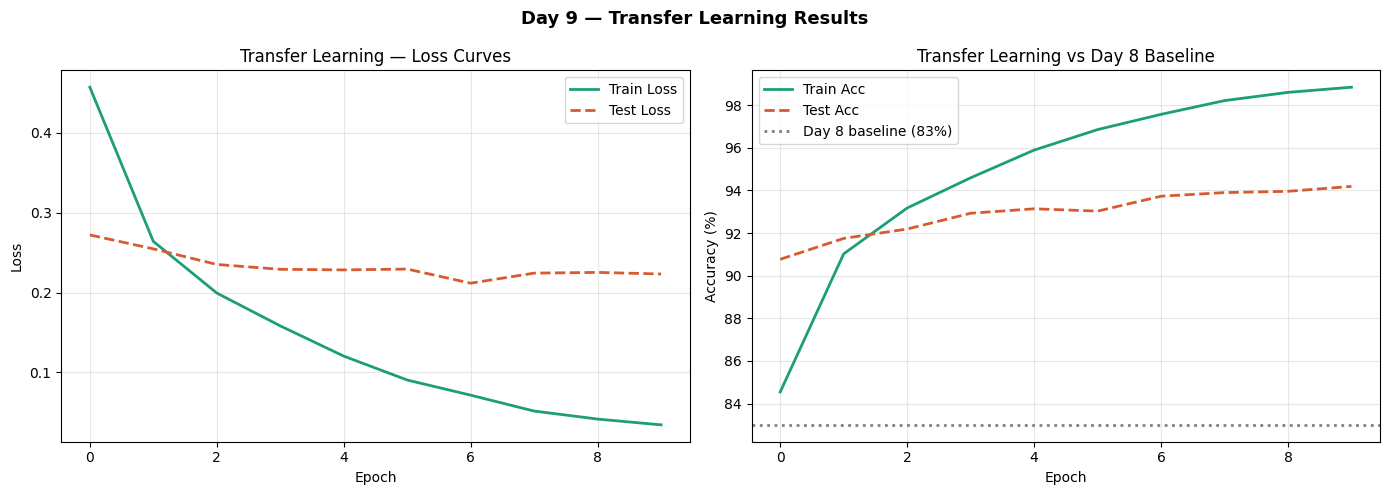

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tl_train_losses, color='#1D9E75',
         linewidth=2, label='Train Loss')
ax1.plot(tl_test_losses,  color='#D85A30',
         linewidth=2, label='Test Loss', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Transfer Learning — Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tl_train_accs, color='#1D9E75',
         linewidth=2, label='Train Acc')
ax2.plot(tl_test_accs,  color='#D85A30',
         linewidth=2, label='Test Acc', linestyle='--')
ax2.axhline(83, color='gray', linestyle=':',
            linewidth=2, label='Day 8 baseline (83%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Transfer Learning vs Day 8 Baseline')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Day 9 — Transfer Learning Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
model_tl.load_state_dict(
    torch.load('best_resnet18_cifar.pth'))
model_tl.eval()

class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_tl(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_total[label]   += 1
            if predicted[i] == labels[i]:
                class_correct[label] += 1
print(f"{'Class':15} {'Accuracy':>10}  {'Bar'}")
print("-" * 50)
for i in range(10):
    acc = class_correct[i] / class_total[i] * 100
    bar = '█' * int(acc / 5)
    print(f"{classes[i]:15} {acc:>8.1f}%  {bar}")

Class             Accuracy  Bar
--------------------------------------------------
airplane            97.0%  ███████████████████
automobile          96.8%  ███████████████████
bird                91.8%  ██████████████████
cat                 84.5%  ████████████████
deer                93.8%  ██████████████████
dog                 92.1%  ██████████████████
frog                97.5%  ███████████████████
horse               96.5%  ███████████████████
ship                96.2%  ███████████████████
truck               95.7%  ███████████████████
